# Weather Prediction

## 1) Imports

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("seattle-weather.csv")
print(df.head())

       date  precipitation  temp_max  temp_min  wind  weather
0  1/1/2012            0.0      12.8       5.0   4.7  drizzle
1  1/2/2012           10.9      10.6       2.8   4.5     rain
2  1/3/2012            0.8      11.7       7.2   2.3     rain
3  1/4/2012           20.3      12.2       5.6   4.7     rain
4  1/5/2012            1.3       8.9       2.8   6.1     rain


## 2) EDA

In [3]:
df.isnull().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

There a no null values in the dataset

In [4]:
print(f'There are {len(df['weather'].unique())} weather types')
print(f'Here is the list of weather types:\n {list(df['weather'].unique())}')

There are 5 weather types
Here is the list of weather types:
 ['drizzle', 'rain', 'sun', 'snow', 'fog']


(0.0, 53.87405886379192)

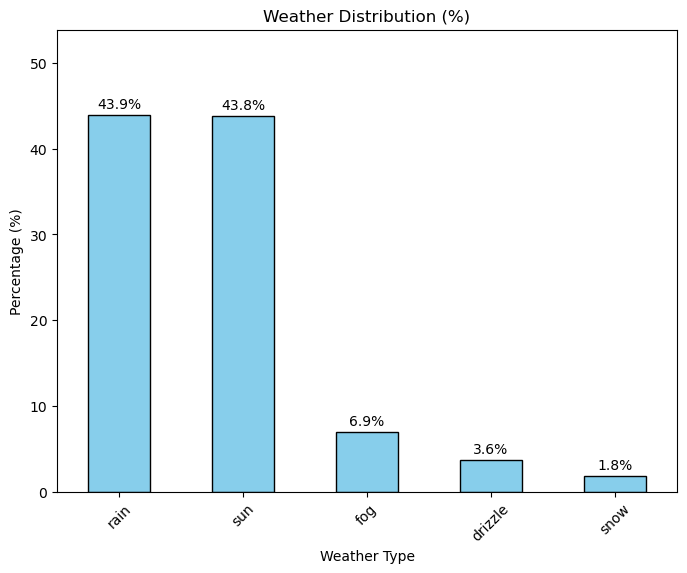

In [5]:
# 1. Calculate the percentage distribution
# normalize=True turns counts into proportions (0.0 to 1.0)
percentages = df['weather'].value_counts(normalize=True) * 100

# 2. Plot the bar chart
ax = percentages.plot(
    kind='bar', 
    figsize=(8, 6), 
    title='Weather Distribution (%)',
    xlabel='Weather Type',
    ylabel='Percentage (%)',
    rot=45,
    color='skyblue',
    edgecolor='black'
)

# 3. Add the percentage labels on top of each bar
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=3)

# Add some breathing room at the top for the labels
ax.set_ylim(0, percentages.max() + 10)

This shows that the data set has unbalanced classes and has more than 2 clasess, indicating that it's a multiclass dataset\
with imbalance

In [6]:
# Stastical Weather Analysis
weather_stats = df.groupby('weather')[['precipitation', 'wind', 'temp_max', 'temp_min']].mean().round(2)

# Rename the columns using a dictionary
weather_stats = weather_stats.rename(columns={
    'precipitation': 'avg.precipitation',
    'wind': 'avg.wind',
    'temp_max': 'avg.temp_max',
    'temp_min': 'avg.temp_min'
})

weather_stats

,avg.precipitation,avg.wind,avg.temp_max,avg.temp_min
weather,,,,
drizzle,0.00,2.37,15.93,7.11
fog,0.00,2.48,16.76,7.98
rain,6.56,3.67,13.45,7.59
snow,8.55,4.41,5.57,0.15
sun,0.00,2.96,19.86,9.34


From what can be understood:
* The Precipitation is 0 for all records of drizzle, fog and sun weather events
* Snow has much lower temperatures (max and min) on average than other weather events (which makes sense)
* Sun, Drizzle and fog weather events tend to have very similar weather stats on avg, however sun events are slightly warmer
    *  This could make it harder for the model to distingish between sun, drizzle and fog weather during the predictions

## 3) Train/Test Set preparation

In [7]:
df1=df.copy()

# Encode the target variable 'weather'
le = LabelEncoder()
df1['weather_encoded'] = le.fit_transform(df['weather'])
df1

,date,precipitation,temp_max,temp_min,wind,weather,weather_encoded
0,1/1/2012,0.0,12.8,5.0,4.7,drizzle,0
1,1/2/2012,10.9,10.6,2.8,4.5,rain,2
2,1/3/2012,0.8,11.7,7.2,2.3,rain,2
3,1/4/2012,20.3,12.2,5.6,4.7,rain,2
4,1/5/2012,1.3,8.9,2.8,6.1,rain,2
...,...,...,...,...,...,...,...
1456,12/27/2015,8.6,4.4,1.7,2.9,rain,2
1457,12/28/2015,1.5,5.0,1.7,1.3,rain,2
1458,12/29/2015,0.0,7.2,0.6,2.6,fog,1
1459,12/30/2015,0.0,5.6,-1.0,3.4,sun,4


In [8]:
def normalize(df,cols):
    for x in cols:
        df[x] = df[x]/df[x].max()

In [9]:
cols = ['precipitation' , 'temp_max', 'temp_min', 'wind']

In [10]:
normalize(df1,cols)
df1

,date,precipitation,temp_max,temp_min,wind,weather,weather_encoded
0,1/1/2012,0.000000,0.359551,0.273224,0.494737,drizzle,0
1,1/2/2012,0.194991,0.297753,0.153005,0.473684,rain,2
2,1/3/2012,0.014311,0.328652,0.393443,0.242105,rain,2
3,1/4/2012,0.363148,0.342697,0.306011,0.494737,rain,2
4,1/5/2012,0.023256,0.250000,0.153005,0.642105,rain,2
...,...,...,...,...,...,...,...
1456,12/27/2015,0.153846,0.123596,0.092896,0.305263,rain,2
1457,12/28/2015,0.026834,0.140449,0.092896,0.136842,rain,2
1458,12/29/2015,0.000000,0.202247,0.032787,0.273684,fog,1
1459,12/30/2015,0.000000,0.157303,-0.054645,0.357895,sun,4


In [11]:
df1.sort_values(by="temp_max", ascending=False)

,date,precipitation,temp_max,temp_min,wind,weather,weather_encoded
953,8/11/2014,0.008945,1.000000,0.972678,0.273684,rain,2
1295,7/19/2015,0.000000,0.983146,0.939891,0.347368,sun,4
228,8/16/2012,0.000000,0.966292,1.000000,0.294737,sun,4
912,7/1/2014,0.000000,0.966292,0.852459,0.368421,sun,4
1306,7/30/2015,0.000000,0.966292,0.939891,0.368421,sun,4
...,...,...,...,...,...,...,...
17,1/18/2012,0.354204,0.000000,-0.153005,0.526316,snow,3
706,12/7/2013,0.000000,0.000000,-0.387978,0.326316,sun,4
766,2/5/2014,0.000000,-0.014045,-0.300546,0.694737,sun,4
18,1/19/2012,0.271914,-0.030899,-0.153005,0.168421,snow,3


In [12]:
# Define features (X) and target (y)
x = df1.drop(columns=['date','weather', 'weather_encoded'])
y = df1['weather_encoded']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

## 4) Model Development (Part 1)

### 4.1) Using Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)

# Display results
print("\u001b[1mClassification Report:\u001b[0m")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        10
         fog       0.09      0.03      0.05        29
        rain       0.96      0.91      0.93       123
        snow       1.00      0.33      0.50         6
         sun       0.71      0.90      0.79       125

    accuracy                           0.78       293
   macro avg       0.55      0.44      0.46       293
weighted avg       0.73      0.78      0.75       293



In [16]:
# Calculate importance and convert to percentage
importances = pd.Series(model.feature_importances_, index=x.columns)
importances_pct = (importances * 100).sort_values(ascending=False)

# Print with formatting
print("\n\u001b[1mFeature Importance (%):\u001b[0m")
print(importances_pct.map('{:.1f}%'.format))


Feature Importance (%):
precipitation    52.5%
temp_max         18.8%
wind             14.4%
temp_min         14.3%
dtype: object


### 4.2) Hyperparameter tuning to improve the Random Forest

In [17]:
from sklearn.model_selection import GridSearchCV

# Define the model
rf = RandomForestClassifier(random_state=42)

# Define the grid of parameters to test
param_grid = {
    'class_weight': [None,'balanced', 'balanced_subsample'],
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Run the grid search
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=10,                 
    scoring='accuracy',  
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [18]:
# Get the best estimator from your GridSearch
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Display results
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        10
         fog       0.20      0.03      0.06        29
        rain       0.97      0.90      0.94       123
        snow       1.00      0.50      0.67         6
         sun       0.71      0.97      0.82       125

    accuracy                           0.81       293
   macro avg       0.58      0.48      0.50       293
weighted avg       0.75      0.81      0.76       293



As a result of the hyperparameter tuning, the model accuracy has improved from **78%** to **81%**

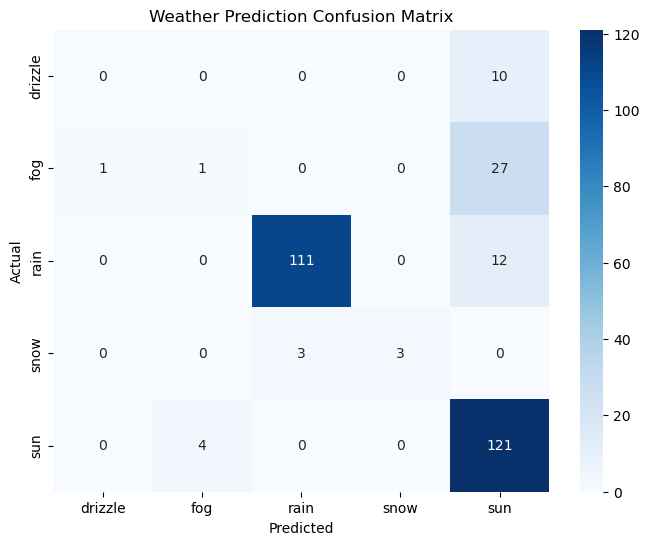

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Check: Plot the Confusion Matrix to see exactly where errors happen
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Weather Prediction Confusion Matrix')
plt.show()

# 5) Feature Engineering

In the confusion matrix above, we can see that while the model is excellent at predicting sun and rain weather, it is very poor at predicting drizzle and fog. This may be due to the fact that there's very little information differentiating between sun, drizzle and fog. So the model is more likely to falsly predict drizzle and fog weather as sun weather, because there is more training data for sun.

##### Due to dataset being small multiclass dataset with imbalance, it may be beneifcial to do some feature engineering where we will use the existing features to generate some new features, that will help provide more information for the machine learning models to differentiate between the weather classes better.

In [20]:
df2 = df.copy()

df2['weather_encoded'] = le.fit_transform(df2['weather'])

# Convert date to datetime object
df2['date'] = pd.to_datetime(df2['date'])

# 1. Ensure data is sorted by date
df2 = df2.sort_values('date')

# Extract useful features from the date
df2['month'] = df2['date'].dt.month
df2['day'] = df2['date'].dt.day

In [21]:
df2

,date,precipitation,temp_max,temp_min,wind,weather,weather_encoded,month,day
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,0,1,1
1,2012-01-02,10.9,10.6,2.8,4.5,rain,2,1,2
2,2012-01-03,0.8,11.7,7.2,2.3,rain,2,1,3
3,2012-01-04,20.3,12.2,5.6,4.7,rain,2,1,4
4,2012-01-05,1.3,8.9,2.8,6.1,rain,2,1,5
...,...,...,...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain,2,12,27
1457,2015-12-28,1.5,5.0,1.7,1.3,rain,2,12,28
1458,2015-12-29,0.0,7.2,0.6,2.6,fog,1,12,29
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun,4,12,30


In [22]:
df2['temp_range']=df2['temp_max']-df2['temp_min']
df2['is_dry_precipitation'] = (df2["precipitation"] == 0).astype(int)
df2['humidity_proxy'] = (df2['temp_range'])/(df['temp_max']+273.15)

In [23]:
# Dictionary mapping each month number to its meteorological season
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

# Assumes your month column is named "month"
df2["season"] = df2["month"].map(season_map)

# Define the order (e.g., chronological starting with Winter)
label_map = {"Winter": 0, "Spring": 1, "Summer": 2, "Autumn": 3}

# Create the encoded numeric column
df2["season_encoded"] = df2["season"].map(label_map)

In [24]:
cols2 = ['temp_range','humidity_proxy']
normalize(df2,cols)
normalize(df2,cols2)

In [25]:
df2

,date,precipitation,temp_max,temp_min,wind,weather,weather_encoded,month,day,temp_range,is_dry_precipitation,humidity_proxy,season,season_encoded
0,2012-01-01,0.000000,0.359551,0.273224,0.494737,drizzle,0,1,1,0.412698,1,0.440698,Winter,0
1,2012-01-02,0.194991,0.297753,0.153005,0.473684,rain,2,1,2,0.412698,0,0.444114,Winter,0
2,2012-01-03,0.014311,0.328652,0.393443,0.242105,rain,2,1,3,0.238095,0,0.255230,Winter,0
3,2012-01-04,0.363148,0.342697,0.306011,0.494737,rain,2,1,4,0.349206,0,0.373682,Winter,0
4,2012-01-05,0.023256,0.250000,0.153005,0.642105,rain,2,1,5,0.322751,0,0.349414,Winter,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2015-12-27,0.153846,0.123596,0.092896,0.305263,rain,2,12,27,0.142857,0,0.157166,Winter,0
1457,2015-12-28,0.026834,0.140449,0.092896,0.136842,rain,2,12,28,0.174603,0,0.191677,Winter,0
1458,2015-12-29,0.000000,0.202247,0.032787,0.273684,fog,1,12,29,0.349206,1,0.380347,Winter,0
1459,2015-12-30,0.000000,0.157303,-0.054645,0.357895,sun,4,12,30,0.349206,1,0.382530,Winter,0


In [26]:
# Define features (X) and target (y)
x2 = df2.drop(columns=['date','weather', 'weather_encoded','season'])
y2 = df2['weather_encoded']

## 6) Model Development (Part 2)

### 6.1) Random forest (with the new features)

In [27]:
X2_train, X2_test, y2_train, y2_test = train_test_split(x2, y2, test_size = 0.2, random_state = 0)

In [28]:
# 4. Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X2_train, y2_train)

# 5. Evaluate the model
y2_pred = model.predict(X2_test)

# Display results
print("\u001b[1mClassification Report:\u001b[0m")
print(classification_report(y2_test, y2_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.50      0.10      0.17        10
         fog       0.38      0.10      0.16        29
        rain       0.97      0.90      0.93       123
        snow       1.00      0.33      0.50         6
         sun       0.73      0.97      0.83       125

    accuracy                           0.81       293
   macro avg       0.71      0.48      0.52       293
weighted avg       0.79      0.81      0.78       293



There is an improvement in accuracy from the original model from **78%** to **81%**, as a result of the new added features

In [29]:
# Calculate importance and convert to percentage
importances = pd.Series(model.feature_importances_, index=x2.columns)
importances_pct = (importances * 100).sort_values(ascending=False)

# Print with formatting
print("\n\u001b[1mFeature Importance (%):\u001b[0m")
print(importances_pct.map('{:.1f}%'.format))


Feature Importance (%):
is_dry_precipitation    25.7%
precipitation           25.2%
humidity_proxy           9.8%
temp_range               8.2%
wind                     7.3%
temp_max                 6.8%
temp_min                 6.8%
day                      5.4%
month                    3.5%
season_encoded           1.2%
dtype: object


#### 6.1.1) Hyperparameter tuning with RF (new features)

In [30]:
# Run the grid search
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=10,                 # 10-fold cross-validation
    scoring='accuracy',   # Crucial: Use f1_macro or f1_weighted instead of 'accuracy'
    n_jobs=-1
)

grid_search.fit(X2_train, y2_train)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [31]:
# 1. Get the best estimator from your GridSearch
best_model = grid_search.best_estimator_

# 2. Predict on the test set
y2_pred = best_model.predict(X2_test)

# Display results
print("\n\u001b[1mClassification Report:\u001b[0m")
print(classification_report(y2_test, y2_pred, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

     drizzle       0.50      0.10      0.17        10
         fog       0.40      0.07      0.12        29
        rain       0.97      0.90      0.94       123
        snow       1.00      0.50      0.67         6
         sun       0.72      0.98      0.83       125

    accuracy                           0.82       293
   macro avg       0.72      0.51      0.54       293
weighted avg       0.79      0.82      0.78       293



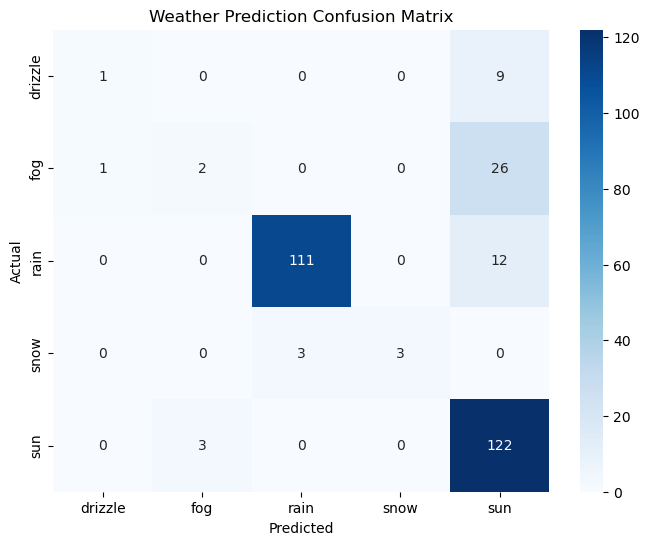

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Check: Plot the Confusion Matrix to see exactly where errors happen
cm = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Weather Prediction Confusion Matrix')
plt.show()

### 6.2) SMOTE (for unbalanced datasets)

To deal with the imbalanced dataset issue better, it may be benefical to create synthetic new samples of the minority classes in the dataset to help with the predictions.

Additionally Due to the imbalanced nature of the dataset and being multiclass, it may be more prefered to use **"f1_macro"** instead of "accuracy" as the scoring metric.

In [33]:
from imblearn.over_sampling import SMOTE  # NEW IMPORT

# 1. Initialize SMOTE
# random_state ensures you get the exact same synthetic data every time you run it
smote = SMOTE(random_state=42)

# 2. Resample ONLY the training data
# This creates synthetic examples for fog, drizzle, and snow in the training set
X_train_balanced, y_train_balanced = smote.fit_resample(X2_train, y2_train)

# 3. Train the model on the newly balanced data
# Note: Do NOT use class_weight='balanced' here, as the data is already balanced
model = RandomForestClassifier(random_state=42)
model.fit(X_train_balanced, y_train_balanced)

# 4. Evaluate the model on the ORIGINAL, untouched test data
y2_pred = model.predict(X2_test)

# Display results
print("\n\u001b[1mClassification Report (With SMOTE):\u001b[0m")
print(classification_report(y2_test, y2_pred, target_names=le.classes_))


Classification Report (With SMOTE):
              precision    recall  f1-score   support

     drizzle       0.12      0.20      0.15        10
         fog       0.33      0.48      0.39        29
        rain       0.98      0.88      0.93       123
        snow       0.57      0.67      0.62         6
         sun       0.78      0.72      0.75       125

    accuracy                           0.74       293
   macro avg       0.55      0.59      0.57       293
weighted avg       0.79      0.74      0.76       293



As you can see, the f1_macro score is **57%** which is much larger than the previous model scores (50% and 52% respectively)

#### 6.2.1) Hyperparameter tuning with SMOTE dataset

In [34]:
# Define the model
rf = RandomForestClassifier(random_state=42)

# Define the grid of parameters to test
param_grid = {
    'class_weight': [None,'balanced', 'balanced_subsample'],
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Run the grid search
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5,                 
    scoring='f1_macro',   # Crucial: Use f1_macro or f1_weighted instead of 'accuracy'
    n_jobs=-1
)

grid_search.fit(X_train_balanced, y_train_balanced)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [35]:
# 1. Get the best estimator from your GridSearch
best_model = grid_search.best_estimator_

# 2. Predict on the test set
y2_pred = best_model.predict(X2_test)

# Display results
print("\n\u001b[1mClassification Report:\u001b[0m")
print(classification_report(y2_test, y2_pred, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

     drizzle       0.11      0.20      0.14        10
         fog       0.34      0.45      0.39        29
        rain       0.98      0.89      0.93       123
        snow       0.67      0.67      0.67         6
         sun       0.78      0.75      0.77       125

    accuracy                           0.76       293
   macro avg       0.58      0.59      0.58       293
weighted avg       0.80      0.76      0.78       293



## 7) XGBoost Model example

In [36]:
from xgboost import XGBClassifier

In [37]:
xg = XGBClassifier()
xg.fit(X2_train, y2_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
xg.get_params()

{'objective': 'multi:softprob',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [39]:
from sklearn.metrics import classification_report, accuracy_score

In [40]:
y_hat = xg.predict(X2_test)
print(accuracy_score(y2_test,y_hat))
print(classification_report(y2_test,y_hat))

0.7918088737201365
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.43      0.21      0.28        29
           2       0.94      0.91      0.93       123
           3       1.00      0.17      0.29         6
           4       0.73      0.90      0.81       125

    accuracy                           0.79       293
   macro avg       0.62      0.44      0.46       293
weighted avg       0.77      0.79      0.77       293



In [41]:
grid = {'learning_rate': [0.1,1, 0.01, 0.001], 'gamma':[0,1,10,100]}

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
model = GridSearchCV(XGBClassifier(), grid, cv=10, verbose=2)

In [44]:
model.fit(X_train, y_train)

Fitting 10 folds for each of 16 candidates, totalling 160 fits
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.8s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.9s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   1.2s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   1.3s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   1.0s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.8s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END ...........................gamma=0, learning_rate=1; total time=   0.6s
[CV] END ...........................gamma=0, l

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'gamma': [0, 1, ...], 'learning_rate': [0.1, 1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [45]:
# Evaluate the best model
best_gb = model.best_estimator_

print(f"Best Parameters: {model.best_params_}")

Best Parameters: {'gamma': 1, 'learning_rate': 0.1}


In [46]:
grid_predictions = model.predict(X_test)
print(accuracy_score(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))

0.8088737201365188
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.33      0.03      0.06        29
           2       0.97      0.90      0.93       123
           3       1.00      0.33      0.50         6
           4       0.72      0.98      0.83       125

    accuracy                           0.81       293
   macro avg       0.60      0.45      0.46       293
weighted avg       0.76      0.81      0.76       293



In [47]:
print(model.best_estimator_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


In [48]:
# 1. Initialize SMOTE
# random_state ensures you get the exact same synthetic data every time you run it
smote = SMOTE(random_state=42)

# 2. Resample ONLY the training data
# This creates synthetic examples for fog, drizzle, and snow in the training set
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

model.fit(X_train_balanced, y_train_balanced)

# 4. Evaluate the model on the ORIGINAL, untouched test data
y_pred = model.predict(X_test)

# Display results
print("Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 10 folds for each of 16 candidates, totalling 160 fits
[CV] END .........................gamma=0, learning_rate=0.1; total time=   1.2s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   1.1s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END .........................gamma=0, learning_rate=0.1; total time=   0.7s
[CV] END ...........................gamma=0, learning_rate=1; total time=   0.6s
[CV] END ...........................gamma=0, l